In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import great_expectations as gx
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Suppress font/findfont warnings on Windows
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'


In [2]:
DATA_PATH = r"C:\Users\Asus\Desktop\python-coding\customer churn\data\raw\Telco-Customer-Churn.csv"
telco_cust_df = pd.read_csv(DATA_PATH)

In [3]:
telco_cust_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
telco_cust_df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


### Convert TotalCharges in float

In [5]:
telco_cust_df["TotalCharges"] = pd.to_numeric(telco_cust_df["TotalCharges"], errors="coerce")
telco_cust_df["TotalCharges"].dtype

dtype('float64')

#### Display data type, missing values, unique count, and the actual unique values.

In [6]:
summary = pd.DataFrame({
    "Data Type": telco_cust_df.dtypes,
    "Missing Values": telco_cust_df.isna().sum(),
    "Unique Count": telco_cust_df.nunique()
})
summary["Unique Values"] = [telco_cust_df[col].unique().tolist() for col in telco_cust_df.columns]
summary

,Data Type,Missing Values,Unique Count,Unique Values
customerID,object,0,7043,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOC..."
gender,object,0,2,"[Female, Male]"
SeniorCitizen,int64,0,2,"[0, 1]"
Partner,object,0,2,"[Yes, No]"
Dependents,object,0,2,"[No, Yes]"
tenure,int64,0,73,"[1, 34, 2, 45, 8, 22, 10, 28, 62, 13, 16, 58, ..."
PhoneService,object,0,2,"[No, Yes]"
MultipleLines,object,0,3,"[No phone service, No, Yes]"
InternetService,object,0,3,"[DSL, Fiber optic, No]"
OnlineSecurity,object,0,3,"[No, Yes, No internet service]"


### Investigate the missing values

In [7]:
print(telco_cust_df["TotalCharges"].isna().sum())

11


In [8]:
telco_cust_df.loc[
    telco_cust_df["TotalCharges"].isna(),
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "Churn"
    ]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,NaN,Two year,No
753,3115-CZMZD,0,20.25,NaN,Two year,No
936,5709-LVOEQ,0,80.85,NaN,Two year,No
1082,4367-NUYAO,0,25.75,NaN,Two year,No
1340,1371-DWPAZ,0,56.05,NaN,Two year,No
3331,7644-OMVMY,0,19.85,NaN,Two year,No
3826,3213-VVOLG,0,25.35,NaN,Two year,No
4380,2520-SGTTA,0,20.00,NaN,Two year,No
5218,2923-ARZLG,0,19.70,NaN,One year,No
6670,4075-WKNIU,0,73.35,NaN,Two year,No


### Missing value Imputation
##### Every one of these customers has:
##### tenure = 0 (They maybe new customers and not completed even one billing cycle)

##### TotalCharges  MonthlyCharges -- tenure
##### If tenure = 0 then TotalCharges = 0

In [9]:
telco_cust_df["TotalCharges"] = (
telco_cust_df["TotalCharges"].fillna(0))

### validate data using great_expectation

In [10]:
print("great_expectations version check ",gx.__version__)

great_expectations version check  1.18.1


In [11]:
# Step 1: Create the Batch (Once)
context = gx.get_context()

data_source = context.data_sources.add_pandas(
    name="telco_source"
)

data_asset = data_source.add_dataframe_asset(
    name="telco_asset"
)

batch_definition = data_asset.add_batch_definition_whole_dataframe(
    name="telco_batch"
)

batch = batch_definition.get_batch(
    batch_parameters={"dataframe": telco_cust_df}
)

In [12]:
# 1. Expected Columns
EXPECTED_COLUMNS = [
    "customerID",
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"
]

In [13]:
# 2. Categorical Rules
CATEGORY_RULES = {

    "gender": [
        "Female",
        "Male"
    ],

    "SeniorCitizen": [
        0,
        1
    ],

    "Partner": [
        "Yes",
        "No"
    ],

    "Dependents": [
        "Yes",
        "No"
    ],

    "PhoneService": [
        "Yes",
        "No"
    ],

    "MultipleLines": [
        "No",
        "Yes",
        "No phone service"
    ],

    "InternetService": [
        "DSL",
        "Fiber optic",
        "No"
    ],

    "OnlineSecurity": [
        "No",
        "Yes",
        "No internet service"
    ],

    "OnlineBackup": [
        "No",
        "Yes",
        "No internet service"
    ],

    "DeviceProtection": [
        "No",
        "Yes",
        "No internet service"
    ],

    "TechSupport": [
        "No",
        "Yes",
        "No internet service"
    ],

    "StreamingTV": [
        "No",
        "Yes",
        "No internet service"
    ],

    "StreamingMovies": [
        "No",
        "Yes",
        "No internet service"
    ],

    "Contract": [
        "Month-to-month",
        "One year",
        "Two year"
    ],

    "PaperlessBilling": [
        "Yes",
        "No"
    ],

    "PaymentMethod": [
        "Electronic check",
        "Mailed check",
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ],

    "Churn": [
        "No",
        "Yes"
    ]
}

In [14]:
# 3. Numerical Rules
NUMERICAL_RULES = {

    "tenure": {
        "min": 0,
        "max": 72
    },

    "MonthlyCharges": {
        "min": 0,
        "max": None
    },

    "TotalCharges": {
        "min": 0,
        "max": None
    }

}

In [15]:
# 4. Null Rules
NULL_RULES = {

    "customerID": False,
    "gender": False,
    "SeniorCitizen": False,
    "Partner": False,
    "Dependents": False,
    "tenure": False,
    "PhoneService": False,
    "MultipleLines": False,
    "InternetService": False,
    "OnlineSecurity": False,
    "OnlineBackup": False,
    "DeviceProtection": False,
    "TechSupport": False,
    "StreamingTV": False,
    "StreamingMovies": False,
    "Contract": False,
    "PaperlessBilling": False,
    "PaymentMethod": False,

    # Original dataset contains 11 blank values
    # which become NaN after pd.to_numeric(errors="coerce")
    "TotalCharges": True,
    "MonthlyCharges": False,
    "Churn": False
}

In [16]:
# 5. Unique Rules
UNIQUE_RULES = {
    "customerID": True
}

In [17]:
# 6. Datatype Rules
DTYPE_RULES = {

    "customerID": "object",

    "gender": "object",

    "SeniorCitizen": "int64",

    "Partner": "object",

    "Dependents": "object",

    "tenure": "int64",

    "PhoneService": "object",

    "MultipleLines": "object",

    "InternetService": "object",

    "OnlineSecurity": "object",

    "OnlineBackup": "object",

    "DeviceProtection": "object",

    "TechSupport": "object",

    "StreamingTV": "object",

    "StreamingMovies": "object",

    "Contract": "object",

    "PaperlessBilling": "object",

    "PaymentMethod": "object",

    "MonthlyCharges": "float64",

    "TotalCharges": "float64",

    "Churn": "object"

}

In [18]:
# 7. Business Rules
BUSINESS_RULES = [

    "customerID must be unique",

    "tenure >= 0",

    "MonthlyCharges >= 0",

    "TotalCharges >= 0",

    "If PhoneService == 'No' then MultipleLines == 'No phone service'",

    "If InternetService == 'No' then OnlineSecurity == 'No internet service'",

    "If InternetService == 'No' then OnlineBackup == 'No internet service'",

    "If InternetService == 'No' then DeviceProtection == 'No internet service'",

    "If InternetService == 'No' then TechSupport == 'No internet service'",

    "If InternetService == 'No' then StreamingTV == 'No internet service'",

    "If InternetService == 'No' then StreamingMovies == 'No internet service'",

    "After cleaning: tenure == 0 => TotalCharges == 0"

]

In [19]:
# Validate all categorical columns
for column, allowed_values in CATEGORY_RULES.items():
    batch.validate(gx.expectations.ExpectColumnValuesToBeInSet(column=column,value_set=allowed_values))

# Validate all numerical columns
for column, rule in NUMERICAL_RULES.items():

    kwargs = {
        "column": column,
        "min_value": rule["min"]
    }

    if rule["max"] is not None:
        kwargs["max_value"] = rule["max"]

    batch.validate(
        gx.expectations.ExpectColumnValuesToBeBetween(**kwargs)
    )

# Validate null constraints
for column, allow_null in NULL_RULES.items():
    if not allow_null:
        batch.validate(
            gx.expectations.ExpectColumnValuesToNotBeNull(
                column=column
            )
        )

# Validate uniqueness
for column, is_unique in UNIQUE_RULES.items():
    if is_unique:
        batch.validate(
            gx.expectations.ExpectColumnValuesToBeUnique(
                column=column
            )
        )

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/10 [00:00<?, ?it/s]

### Drop customerID column

In [20]:
telco_cust_df = telco_cust_df.drop('customerID', axis=1)

### Binary Encoding
##### (for columns with only two categories)

In [21]:
binary_mapping = {
    "Yes": 1,
    "No": 0,
    "Male": 1,
    "Female": 0
}

binary_columns = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

for col in binary_columns:
    telco_cust_df[col] = telco_cust_df[col].map(binary_mapping)

telco_cust_df["SeniorCitizen"] = telco_cust_df["SeniorCitizen"].astype(int)

### Create Ordinal Feature (Instead of using Contract as text for VIF)

In [22]:
contract_mapping = {
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
}
telco_cust_df["ContractRank"] = telco_cust_df["Contract"].map(contract_mapping)

### Compute Correlation among numerical features

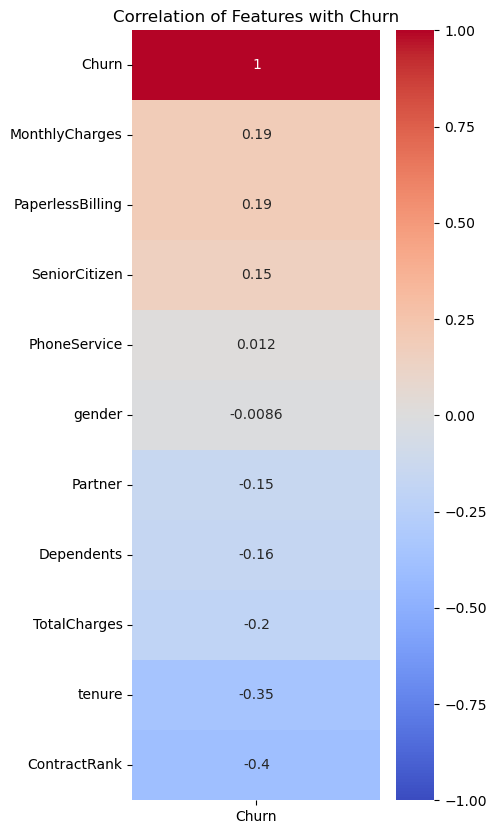

In [23]:
corr_matrix = telco_cust_df.corr(numeric_only=True)
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)

# Compute correlation matrix only for numeric columns
corr_matrix = telco_cust_df.corr(numeric_only=True)

# Focus on correlation with Churn
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)

# Plot heatmap
plt.figure(figsize=(4, 10))
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Features with Churn')
plt.show()

### Calculate VIF

In [24]:
numeric_df = telco_cust_df.select_dtypes(include=["int64", "float64"]).copy()
X_vif = numeric_df.drop(columns=["Churn"])

In [25]:
vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]
vif_df = vif_df.sort_values(
    by="VIF",
    ascending=False
)

In [26]:
# Interpretation

def interpret_vif(vif):
    if vif < 5:
        return "Low"
    elif vif < 10:
        return "Moderate"
    return "High"

vif_df["Interpretation"] = vif_df["VIF"].apply(interpret_vif)
display(vif_df)

,Feature,VIF,Interpretation
7,MonthlyCharges,14.352493,High
4,tenure,14.205769,High
8,TotalCharges,12.734058,High
5,PhoneService,8.174179,Moderate
9,ContractRank,3.627942,Low
6,PaperlessBilling,2.846078,Low
2,Partner,2.816346,Low
3,Dependents,1.944771,Low
0,gender,1.922586,Low
1,SeniorCitizen,1.343586,Low


### one hot encoding(for more than 2 categories)

##### MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies,Contract, PaymentMethod

In [27]:
telco_cust_df.drop(columns=["ContractRank"], inplace=True)

In [28]:
# Categorical columns with > 2 unique values
nominal_columns = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]
# One-hot encode
telco_cust_df = pd.get_dummies(telco_cust_df, columns=nominal_columns, drop_first=True, dtype=int)

In [29]:
bool_cols = telco_cust_df.select_dtypes(include='bool').columns
telco_cust_df[bool_cols] = telco_cust_df[bool_cols].astype(int) # converts True/False to 1/0 for all boolean cols

In [30]:
telco_cust_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [31]:
telco_cust_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


## Look for multicolinearity (VIF)

In [32]:
# We need to collapse redundant columns before running VIF
telco_cust_df['No_internet_service'] = (
    telco_cust_df['OnlineSecurity_No internet service'] |
    telco_cust_df['OnlineBackup_No internet service'] |
    telco_cust_df['DeviceProtection_No internet service'] |
    telco_cust_df['TechSupport_No internet service'] |
    telco_cust_df['StreamingTV_No internet service'] |
    telco_cust_df['StreamingMovies_No internet service']
).astype(int)

# Drop the original redundant dummies
drop_cols = [col for col in telco_cust_df.columns if 'No internet service' in col]
telco_cust_df = telco_cust_df.drop(columns=drop_cols)

# Handle PhoneService redundancy
if 'MultipleLines_No phone service' in telco_cust_df.columns:
    telco_cust_df['No_phone_service'] = telco_cust_df['MultipleLines_No phone service'].astype(int)
    telco_cust_df = telco_cust_df.drop(columns=['MultipleLines_No phone service'])

In [33]:
# Prepare X
X = telco_cust_df.drop(columns=['Churn'])
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [34]:
# Run VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Remove rows with missing or infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data)

                                  feature          VIF
23                    No_internet_service          inf
11                     InternetService_No          inf
5                            PhoneService  1770.644580
7                          MonthlyCharges   865.062147
10            InternetService_Fiber optic   148.263380
24                       No_phone_service    60.867536
17                    StreamingMovies_Yes    24.110253
16                        StreamingTV_Yes    24.056827
8                            TotalCharges    10.793729
4                                  tenure     7.527280
9                       MultipleLines_Yes     7.273906
14                   DeviceProtection_Yes     6.922434
13                       OnlineBackup_Yes     6.782866
15                        TechSupport_Yes     6.467893
12                     OnlineSecurity_Yes     6.336249
19                      Contract_Two year     2.632246
21         PaymentMethod_Electronic check     1.976144
22        

- There's multicolinearity between features.
- Possible Solution are
    1. Drop some features.
    2. Use regularization techniques like Lasso or Ridge regression to handle multicolinearity.
    3. Use tree based models which are less sensitive to multicollinearity.

## Machine learning

In [35]:
# We have a class imbalance problem
telco_cust_df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

Typical priority
- If retention campaigns are cheap >' prioritize recall (catch every possible churner).
- If retention campaigns are expensive >' balance precision and recall using F1 score or a precision-recall trade-off.
- If business wants a ranking of churn risk >' use ROC-AUC or PR-AUC to evaluate the model.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import time

In [37]:
# Prepare features and target
X = telco_cust_df.drop(columns=['Churn'])
y = telco_cust_df['Churn']

# Stratified split preserves class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean():.3f}  |  Test churn rate: {y_test.mean():.3f}')

Train: (5634, 25)  |  Test: (1409, 25)
Train churn rate: 0.265  |  Test churn rate: 0.265


---
## Modeling Setup

Import all required libraries

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (RandomizedSearchCV, GridSearchCV, StratifiedKFold, cross_val_score)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, classification_report
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import shap
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
from scipy.stats import randint, uniform
import os, warnings, time
warnings.filterwarnings('ignore')
try:
    shap.initjs()  # Only works in Jupyter; safe to ignore elsewhere
except Exception:
    pass

RANDOM_STATE = 42
CV_FOLDS     = 5
MLFLOW_URI   = 'sqlite:///mlflow.db'  # MLflow 3.x requires DB backend

# Storage for leaderboard
results_list = []

### Feature Scaling

Logistic Regression is sensitive to feature magnitude -- gradient-based solvers
converge faster and the regularisation penalty is fairly applied when all features
are on the same scale. Tree-based models are **invariant** to monotone
transformations, so we keep both scaled and unscaled versions.

In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit only on train
X_test_scaled  = scaler.transform(X_test)        # apply same transform to test

print('Scaled train shape:', X_train_scaled.shape)
print('Scaled test  shape:', X_test_scaled.shape)

Scaled train shape: (5634, 25)
Scaled test  shape: (1409, 25)


---
## Reusable Helper Functions

All modelling steps are encapsulated in helper functions to follow **DRY** principles.
Each model variant calls the same pipeline: train >' tune >' evaluate >' plot >' threshold-opt >' MLflow log.

In [40]:
# -"-" 1. Train -"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"
def train_model(model, X_tr, y_tr):
    """Fit model and return (fitted_model, training_time_seconds)."""
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    return model, round(time.perf_counter() - t0, 4)


# -"-" 2. Hyper-parameter Tuning -"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"
def tune_model(estimator, param_dist, X_tr, y_tr,
               n_iter=30, cv=CV_FOLDS, scoring='roc_auc',
               refine_grid=None):
    """
    Phase 1: RandomizedSearchCV (broad search).
    Phase 2: GridSearchCV around best params if refine_grid is provided.
    Returns the best estimator.
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)

    rscv = RandomizedSearchCV(
        estimator, param_dist, n_iter=n_iter, cv=skf,
        scoring=scoring, n_jobs=-1,
        random_state=RANDOM_STATE, verbose=0
    )
    rscv.fit(X_tr, y_tr)
    print(f'  RandomizedSearchCV best {scoring}: {rscv.best_score_:.4f}')
    print(f'  Best params: {rscv.best_params_}')
    best = rscv.best_estimator_

    if refine_grid:
        gscv = GridSearchCV(
            estimator, refine_grid, cv=skf,
            scoring=scoring, n_jobs=-1, verbose=0
        )
        gscv.fit(X_tr, y_tr)
        if gscv.best_score_ > rscv.best_score_:
            print(f'  GridSearchCV improved to: {gscv.best_score_:.4f}')
            best = gscv.best_estimator_

    return best


# -"-" 3. Evaluate -"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"
def evaluate_model(model, X_te, y_te, threshold=0.5):
    """
    Compute classification metrics at a given decision threshold.
    Returns a metrics dict.
    """
    y_proba = model.predict_proba(X_te)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)

    t0   = time.perf_counter()
    _    = model.predict(X_te)
    inf_time = round(time.perf_counter() - t0, 6)

    return {
        'accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'recall'   : round(recall_score(y_te, y_pred), 4),
        'f1'       : round(f1_score(y_te, y_pred), 4),
        'roc_auc'  : round(roc_auc_score(y_te, y_proba), 4),
        'pr_auc'   : round(average_precision_score(y_te, y_proba), 4),
        'threshold': threshold,
        'inf_time' : inf_time,
        'y_proba'  : y_proba,
        'y_pred'   : y_pred,
    }


# -"-" 4. Threshold Optimisation -"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"
def threshold_optimization(y_true, y_proba, metric='f1'):
    """
    Sweep decision thresholds and return the one that maximises F1.
    F1 balances precision and recall --" ideal when both false-positives
    (wasted retention spend) and false-negatives (missed churners) matter.
    """
    thresholds = np.arange(0.10, 0.91, 0.01)
    scores = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        scores.append(f1_score(y_true, y_pred, zero_division=0))

    best_idx = int(np.argmax(scores))
    best_t   = round(thresholds[best_idx], 2)
    best_f1  = round(scores[best_idx], 4)

    plt.figure(figsize=(7, 3))
    plt.plot(thresholds, scores, color='steelblue')
    plt.axvline(best_t, color='crimson', linestyle='--',
                label=f'Best threshold={best_t}  F1={best_f1}')
    plt.xlabel('Threshold'); plt.ylabel('F1 Score')
    plt.title('Threshold Optimisation')
    plt.legend(); plt.tight_layout(); plt.show()

    print(f'  Optimal threshold: {best_t}  |  F1: {best_f1}')
    return best_t


# -"-" 5. Confusion Matrix -"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"
def plot_confusion_matrix(y_true, y_pred, model_name, ax=None):
    cm = confusion_matrix(y_true, y_pred)
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix -- {model_name}')
    if standalone:
        plt.tight_layout(); plt.show()


# -"-" 6. ROC Curve -"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"
def plot_roc_curve(y_true, y_proba, model_name, ax=None, color=None):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc_val = roc_auc_score(y_true, y_proba)
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 4))
    kw = dict(label=f'{model_name} (AUC={auc_val:.3f})')
    if color: kw['color'] = color
    ax.plot(fpr, tpr, **kw)
    if standalone:
        ax.plot([0,1],[0,1],'k--')
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.set_title('ROC Curve'); ax.legend()
        plt.tight_layout(); plt.show()
    return fpr, tpr, auc_val


# -"-" 7. Precision-Recall Curve -"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"
def plot_pr_curve(y_true, y_proba, model_name, ax=None, color=None):
    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 4))
    kw = dict(label=f'{model_name} (AP={ap:.3f})')
    if color: kw['color'] = color
    ax.plot(rec, prec, **kw)
    if standalone:
        ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
        ax.set_title('Precision-Recall Curve'); ax.legend()
        plt.tight_layout(); plt.show()
    return prec, rec, ap


# -"-" 8. Full Model Workflow -"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"
def run_model_workflow(name, model, param_dist, X_tr, y_tr, X_te, y_te,
                       refine_grid=None, feature_names=None,
                       early_stopping_rounds=None, eval_set=None):
    """
    End-to-end pipeline for one model:
      baseline ->+' tuning ->+' evaluation ->+' plots ->+' threshold opt ->+' results dict.
    """
    sep = '='*60
    print('' + sep)
    print(f'  {name}')
    print(sep)

    # --- Baseline ----------------------------------------
    print('  [1/4] Training baseline ...')
    baseline, train_time = train_model(model, X_tr, y_tr)
    base_metrics = evaluate_model(baseline, X_te, y_te)
    print(f'  Baseline ROC-AUC: {base_metrics["roc_auc"]}  F1: {base_metrics["f1"]}')

    # --- Tuning ----------------------------------------
    print('  [2/4] Hyper-parameter tuning ...')
    best_model = tune_model(model, param_dist, X_tr, y_tr,
                            refine_grid=refine_grid)
    best_model, train_time = train_model(best_model, X_tr, y_tr)

    # --- Evaluation ----------------------------------------
    print('  [3/4] Evaluating on test set ...')
    metrics = evaluate_model(best_model, X_te, y_te)
    print(f'  Tuned  ROC-AUC: {metrics["roc_auc"]}  F1: {metrics["f1"]}')

    # --- Plots ----------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(name, fontsize=13, fontweight='bold')
    plot_confusion_matrix(y_te, metrics['y_pred'], name, ax=axes[0])
    plot_roc_curve(y_te, metrics['y_proba'], name, ax=axes[1])
    axes[1].plot([0,1],[0,1],'k--'); axes[1].legend()
    plot_pr_curve(y_te, metrics['y_proba'], name, ax=axes[2])
    axes[2].legend()
    plt.tight_layout(); plt.show()

    # --- Threshold Optimisation ----------------------------------------
    print('  [4/4] Threshold optimisation ...')
    best_t = threshold_optimization(y_te, metrics['y_proba'])
    opt_metrics = evaluate_model(best_model, X_te, y_te, threshold=best_t)

    print(f'\n  Final Classification Report (threshold={best_t}):')
    print(classification_report(y_te, opt_metrics['y_pred'],
                                target_names=['No Churn','Churn']))

    result = {
        'Model'       : name,
        'Accuracy'    : opt_metrics['accuracy'],
        'Precision'   : opt_metrics['precision'],
        'Recall'      : opt_metrics['recall'],
        'F1'          : opt_metrics['f1'],
        'ROC-AUC'     : opt_metrics['roc_auc'],
        'PR-AUC'      : opt_metrics['pr_auc'],
        'Best Threshold': best_t,
        'Train Time (s)': train_time,
        'Inf Time (s)': opt_metrics['inf_time'],
        '_model'      : best_model,
        '_y_proba'    : opt_metrics['y_proba'],
    }
    return result


# -"-" 9. MLflow Logging -"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"
def log_mlflow_run(result, X_te, y_te, experiment_name='customer_churn',
                   feature_names=None):
    """
    Log a model result dict to MLflow:
      - Parameters (from model.get_params)
      - Metrics
      - Artifacts: confusion matrix, ROC, PR curve, feature importance
    """
    mlflow.set_experiment(experiment_name)
    model     = result['_model']
    y_proba   = result['_y_proba']
    threshold = result['Best Threshold']
    y_pred    = (y_proba >= threshold).astype(int)
    art_dir   = 'mlflow_artifacts'
    os.makedirs(art_dir, exist_ok=True)

    with mlflow.start_run(run_name=result['Model']) as run:
        # Params
        try:
            params = {k: str(v) for k, v in model.get_params().items()}
            mlflow.log_params(params)
        except Exception:
            pass
        mlflow.log_param('best_threshold', threshold)

        # Metrics
        mlflow.log_metric('accuracy',  result['Accuracy'])
        mlflow.log_metric('precision', result['Precision'])
        mlflow.log_metric('recall',    result['Recall'])
        mlflow.log_metric('f1',        result['F1'])
        mlflow.log_metric('roc_auc',   result['ROC-AUC'])
        mlflow.log_metric('pr_auc',    result['PR-AUC'])
        mlflow.log_metric('train_time_s', result['Train Time (s)'])
        mlflow.log_metric('inf_time_s',   result['Inf Time (s)'])

        safe_name = result['Model'].replace(' ', '_').replace('(', '').replace(')', '')

        # Confusion matrix artifact
        fig, ax = plt.subplots(figsize=(4, 3))
        plot_confusion_matrix(y_te, y_pred, result['Model'], ax=ax)
        cm_path = f'{art_dir}/{safe_name}_cm.png'
        fig.savefig(cm_path, bbox_inches='tight'); plt.close(fig)
        mlflow.log_artifact(cm_path)

        # ROC curve artifact
        fig, ax = plt.subplots(figsize=(5, 4))
        plot_roc_curve(y_te, y_proba, result['Model'], ax=ax)
        ax.plot([0,1],[0,1],'k--'); ax.legend()
        roc_path = f'{art_dir}/{safe_name}_roc.png'
        fig.savefig(roc_path, bbox_inches='tight'); plt.close(fig)
        mlflow.log_artifact(roc_path)

        # PR curve artifact
        fig, ax = plt.subplots(figsize=(5, 4))
        plot_pr_curve(y_te, y_proba, result['Model'], ax=ax)
        ax.legend()
        pr_path = f'{art_dir}/{safe_name}_pr.png'
        fig.savefig(pr_path, bbox_inches='tight'); plt.close(fig)
        mlflow.log_artifact(pr_path)

        # Feature importance artifact (tree / boosting models)
        if hasattr(model, 'feature_importances_') and feature_names is not None:
            fi = pd.Series(model.feature_importances_, index=feature_names)
            fi = fi.sort_values(ascending=False).head(20)
            fig, ax = plt.subplots(figsize=(7, 5))
            fi.plot(kind='barh', ax=ax)
            ax.invert_yaxis()
            ax.set_title(f'Feature Importance -- {result["Model"]}')
            fi_path = f'{art_dir}/{safe_name}_fi.png'
            fig.savefig(fi_path, bbox_inches='tight'); plt.close(fig)
            mlflow.log_artifact(fi_path)

        # Log model - handle different flavors and MLflow 3.x skops trust
        try:
            from catboost import CatBoostClassifier as _CB
            _is_catboost = isinstance(model, _CB)
        except Exception:
            _is_catboost = False
        try:
            if _is_catboost:
                import mlflow.catboost as _mlflow_cb
                _mlflow_cb.log_model(model, name='model')
            else:
                import mlflow.sklearn as _mlflow_sk
                _mlflow_sk.log_model(
                    model, name='model',
                    skops_trusted_types=[type(model).__module__ + '.' + type(model).__qualname__]
                )
        except Exception as _e:
            import mlflow as _mlflow_main
            _mlflow_main.log_param('model_log_warning', str(_e)[:100])

        print(f'  MLflow run logged: {run.info.run_id}')
        return run.info.run_id

print('Helper functions defined.')

Helper functions defined.


---
## Part 1 -- Regularized Logistic Regression

### Why Logistic Regression?
Logistic Regression is an interpretable, fast, and probabilistic baseline for binary
classification. It produces well-calibrated probabilities -- essential for threshold
optimisation -- and is the go-to sanity-check model before adding complexity.

### Handling Multicollinearity
VIF analysis revealed high multicollinearity among `MonthlyCharges`, `TotalCharges`,
and `tenure`. Rather than dropping columns we apply regularisation:
- **L2 (Ridge)** -- shrinks all coefficients continuously, distributes weight among
  correlated features.
- **L1 (Lasso)** -- sets some coefficients exactly to zero, performing implicit
  feature selection.
- **Elastic Net** -- linear combination of L1 and L2, capturing benefits of both.

### Hyperparameters Tuned
| Parameter | Description |
|-----------|-------------|
| `C` | Inverse regularisation strength (smaller >' stronger penalty) |
| `l1_ratio` | Elastic Net mixing (0=L2, 1=L1) |
| `solver` | Optimisation algorithm |
| `max_iter` | Maximum gradient-descent iterations |

**`class_weight='balanced'`** is used throughout to compensate for the
~73 / 27 class imbalance.

### 1.1 Ridge Logistic Regression (L2)

**Advantages:** Stable under multicollinearity; keeps all features; well-studied.

**Disadvantages:** Does not perform feature selection; all features remain in the model.

  Ridge LR (L2)
  [1/4] Training baseline ...
  Baseline ROC-AUC: 0.8414  F1: 0.6128
  [2/4] Hyper-parameter tuning ...
  RandomizedSearchCV best roc_auc: 0.8462
  Best params: {'solver': 'lbfgs', 'max_iter': 500, 'C': 10}
  [3/4] Evaluating on test set ...
  Tuned  ROC-AUC: 0.8406  F1: 0.6143


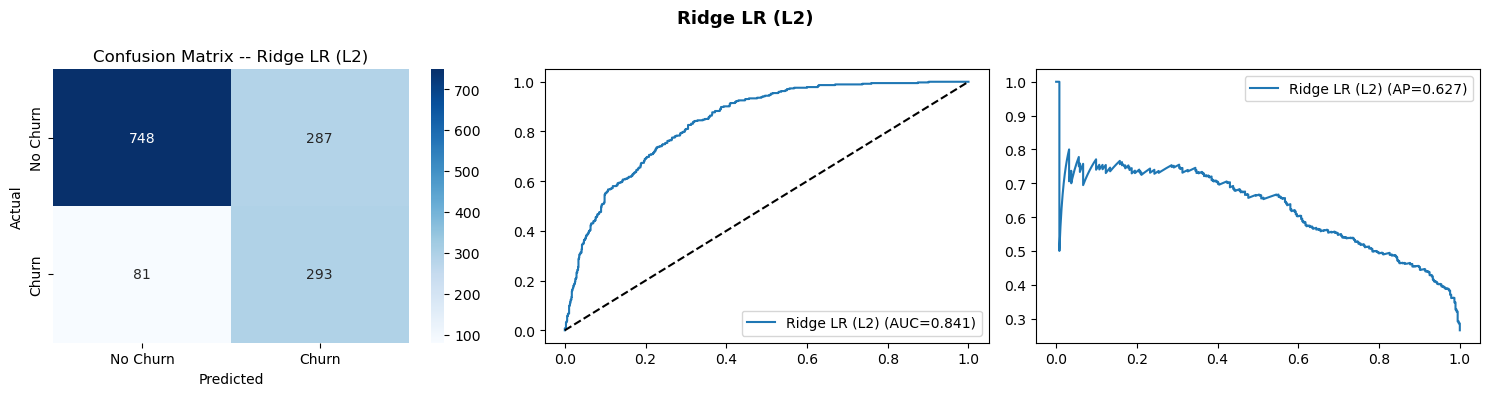

  [4/4] Threshold optimisation ...


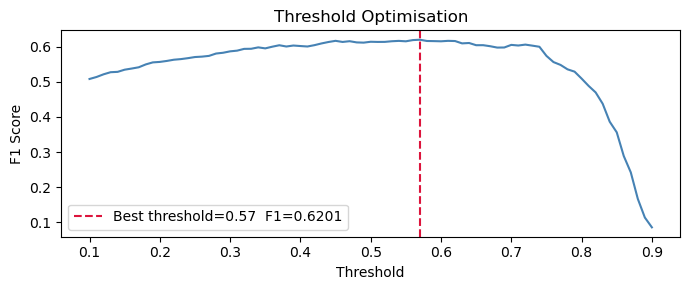

  Optimal threshold: 0.57  |  F1: 0.6201

  Final Classification Report (threshold=0.57):
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.83      1035
       Churn       0.54      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [41]:
ridge_param_dist = {
    'C'       : [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
    'solver'  : ['lbfgs', 'saga'],
    'max_iter': [500, 1000, 2000],
}

ridge_results = run_model_workflow(
    name        = 'Ridge LR (L2)',
    model       = LogisticRegression(penalty='l2', class_weight='balanced',
                                     random_state=RANDOM_STATE),
    param_dist  = ridge_param_dist,
    X_tr        = X_train_scaled,
    y_tr        = y_train,
    X_te        = X_test_scaled,
    y_te        = y_test,
)
results_list.append(ridge_results)

### 1.2 Lasso Logistic Regression (L1)

**Advantages:** Automatic feature selection via zero coefficients; sparse model;
easier to interpret.

**Disadvantages:** May discard useful correlated features; less stable than Ridge
when predictors are highly correlated.

  Lasso LR (L1)
  [1/4] Training baseline ...
  Baseline ROC-AUC: 0.8416  F1: 0.6136
  [2/4] Hyper-parameter tuning ...
  RandomizedSearchCV best roc_auc: 0.8462
  Best params: {'solver': 'saga', 'max_iter': 1000, 'C': 5}
  [3/4] Evaluating on test set ...
  Tuned  ROC-AUC: 0.8407  F1: 0.6143


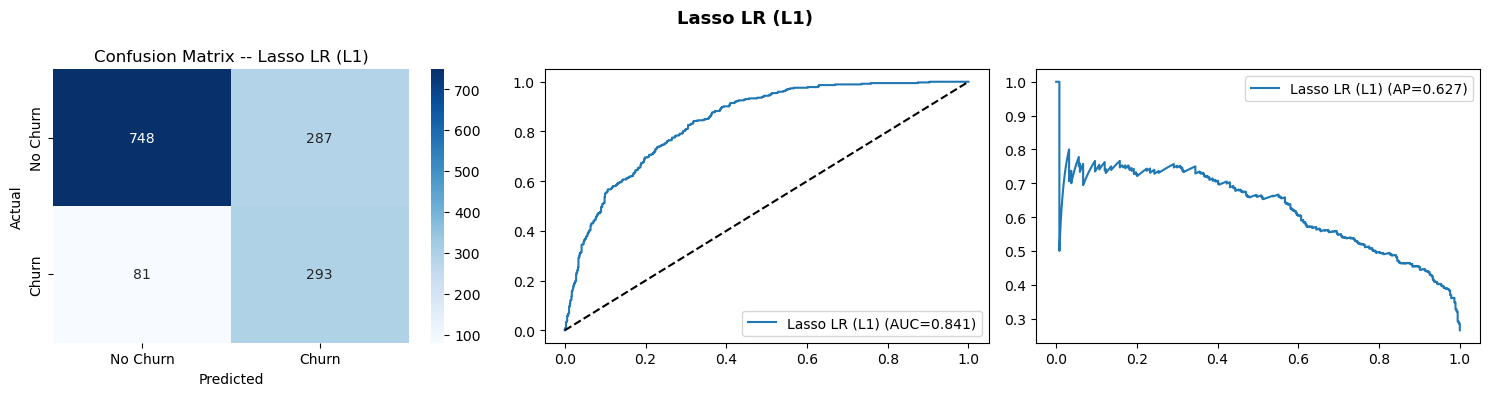

  [4/4] Threshold optimisation ...


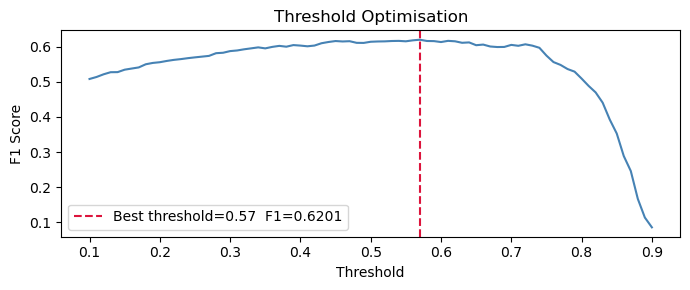

  Optimal threshold: 0.57  |  F1: 0.6201

  Final Classification Report (threshold=0.57):
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.83      1035
       Churn       0.54      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [42]:
lasso_param_dist = {
    'C'       : [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
    'solver'  : ['liblinear', 'saga'],
    'max_iter': [500, 1000, 2000],
}

lasso_results = run_model_workflow(
    name       = 'Lasso LR (L1)',
    model      = LogisticRegression(penalty='l1', solver='liblinear',
                                    class_weight='balanced',
                                    random_state=RANDOM_STATE),
    param_dist = lasso_param_dist,
    X_tr       = X_train_scaled,
    y_tr       = y_train,
    X_te       = X_test_scaled,
    y_te       = y_test,
)
results_list.append(lasso_results)

### 1.3 Elastic Net Logistic Regression

**Advantages:** Combines L1 sparsity and L2 stability; performs well when there are
groups of correlated features.

**Disadvantages:** Introduces a second hyper-parameter (`l1_ratio`), making tuning
more complex; only supported by the `saga` solver.

  Elastic Net LR
  [1/4] Training baseline ...
  Baseline ROC-AUC: 0.8416  F1: 0.6149
  [2/4] Hyper-parameter tuning ...
  RandomizedSearchCV best roc_auc: 0.8462
  Best params: {'max_iter': 2000, 'l1_ratio': 0.3, 'C': 10}
  [3/4] Evaluating on test set ...
  Tuned  ROC-AUC: 0.8406  F1: 0.6143


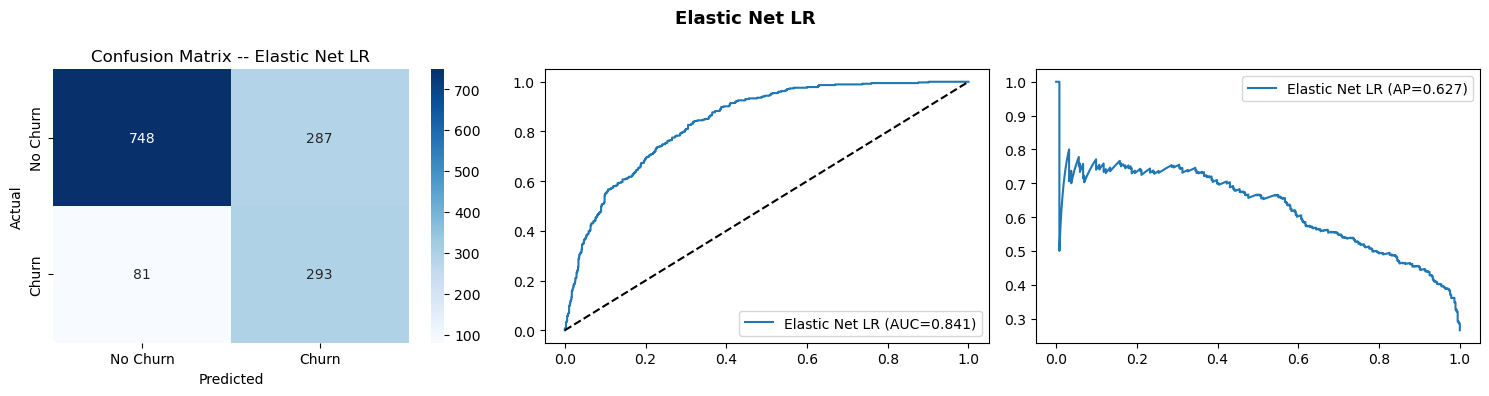

  [4/4] Threshold optimisation ...


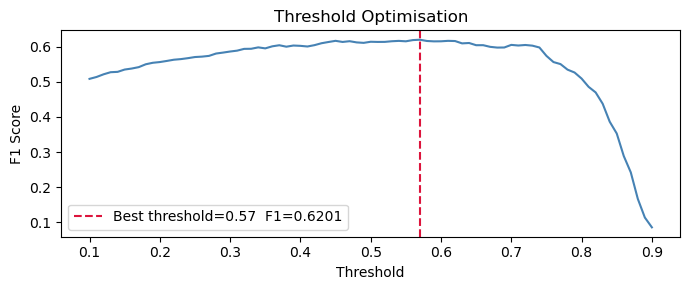

  Optimal threshold: 0.57  |  F1: 0.6201

  Final Classification Report (threshold=0.57):
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.83      1035
       Churn       0.54      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [43]:
enet_param_dist = {
    'C'        : [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 100],
    'l1_ratio' : [0.1, 0.2, 0.3, 0.5, 0.7, 0.9],
    'max_iter' : [1000, 2000, 3000],
}

enet_results = run_model_workflow(
    name       = 'Elastic Net LR',
    model      = LogisticRegression(penalty='elasticnet', solver='saga',
                                    l1_ratio=0.5,
                                    class_weight='balanced',
                                    random_state=RANDOM_STATE),
    param_dist = enet_param_dist,
    X_tr       = X_train_scaled,
    y_tr       = y_train,
    X_te       = X_test_scaled,
    y_te       = y_test,
)
results_list.append(enet_results)

---
## Part 2 -- Tree-Based Models

Tree-based models split data using feature thresholds -- multicollinearity does not
affect them because they select the most discriminative feature at each split
rather than estimating linear coefficients. They can therefore use all features
(`MonthlyCharges`, `TotalCharges`, `tenure`) without regularisation.

**No feature scaling required** for tree-based models.

### 2.1 Decision Tree

**Advantages:** Fully interpretable; handles non-linear relationships; no scaling
needed; fast inference.

**Disadvantages:** High variance -- tends to overfit without depth constraints;
sensitive to small data changes.

### Hyperparameters Tuned
| Parameter | Description |
|-----------|-------------|
| `max_depth` | Maximum tree depth (controls complexity) |
| `min_samples_split` | Min samples to split a node |
| `min_samples_leaf` | Min samples in a leaf |
| `criterion` | Split quality measure (gini / entropy) |

  Decision Tree
  [1/4] Training baseline ...
  Baseline ROC-AUC: 0.6482  F1: 0.4816
  [2/4] Hyper-parameter tuning ...
  RandomizedSearchCV best roc_auc: 0.8293
  Best params: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 25, 'min_samples_split': 15}
  [3/4] Evaluating on test set ...
  Tuned  ROC-AUC: 0.8327  F1: 0.6183


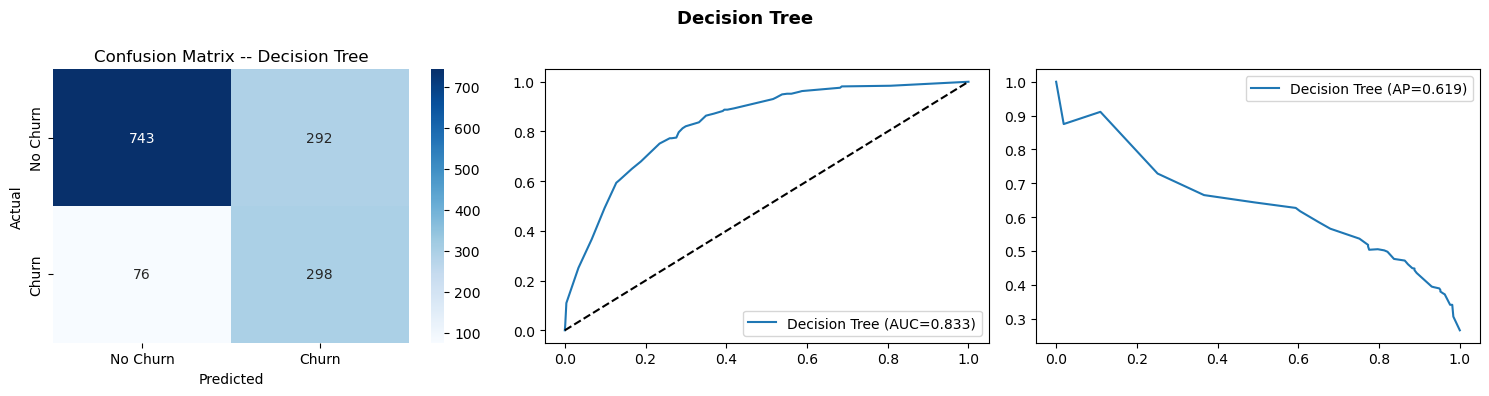

  [4/4] Threshold optimisation ...


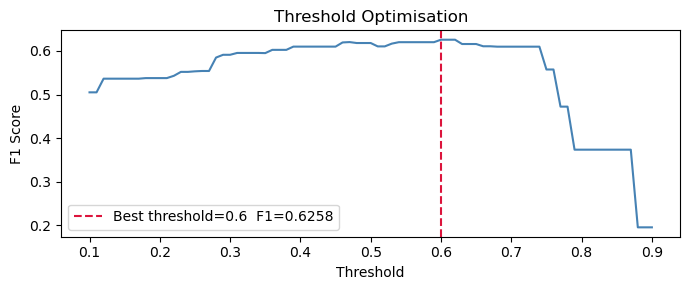

  Optimal threshold: 0.6  |  F1: 0.6258

  Final Classification Report (threshold=0.6):
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.82      1035
       Churn       0.54      0.75      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



In [44]:
dt_param_dist = {
    'max_depth'        : [3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': randint(2, 50),
    'min_samples_leaf' : randint(1, 30),
    'criterion'        : ['gini', 'entropy'],
    'class_weight'     : ['balanced', None],
}

dt_results = run_model_workflow(
    name       = 'Decision Tree',
    model      = DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_dist = dt_param_dist,
    X_tr       = X_train,
    y_tr       = y_train,
    X_te       = X_test,
    y_te       = y_test,
)
results_list.append(dt_results)

### 2.2 Random Forest

**Advantages:** Reduces Decision Tree variance via bagging + random feature subsets;
robust to outliers; provides feature importances; generally strong out-of-the-box.

**Disadvantages:** Less interpretable than a single tree; slower training; higher
memory footprint.

### Hyperparameters Tuned
| Parameter | Description |
|-----------|-------------|
| `n_estimators` | Number of trees |
| `max_depth` | Maximum tree depth |
| `max_features` | Features considered per split (`sqrt` / `log2`) |
| `min_samples_leaf` | Min leaf samples |
| `bootstrap` | Whether to use bootstrap sampling |

  Random Forest
  [1/4] Training baseline ...
  Baseline ROC-AUC: 0.8269  F1: 0.549
  [2/4] Hyper-parameter tuning ...
  RandomizedSearchCV best roc_auc: 0.8477
  Best params: {'bootstrap': True, 'max_depth': 7, 'max_features': 0.5, 'min_samples_leaf': 15, 'min_samples_split': 20, 'n_estimators': 400}
  [3/4] Evaluating on test set ...
  Tuned  ROC-AUC: 0.846  F1: 0.6372


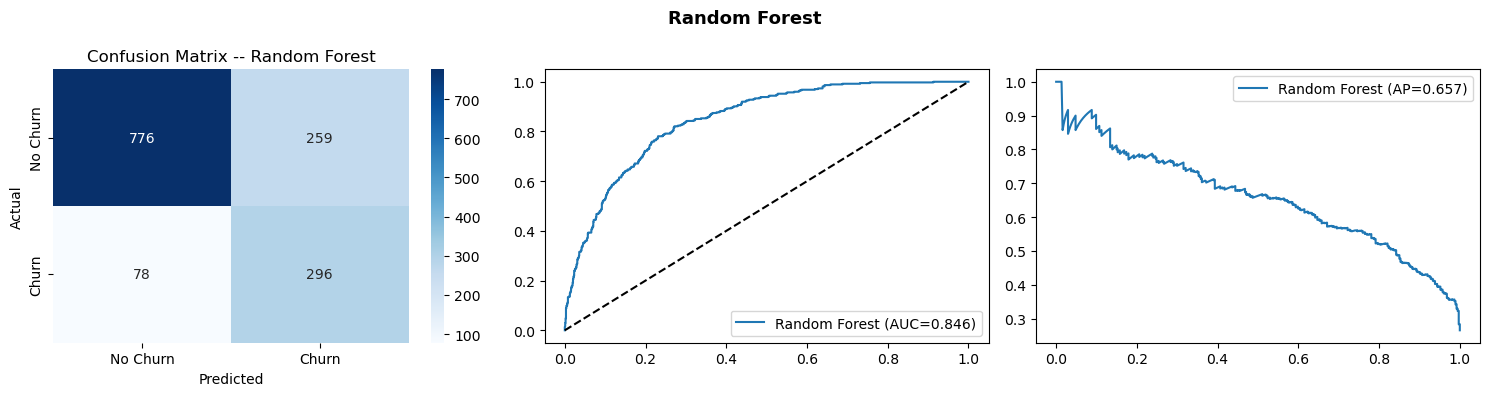

  [4/4] Threshold optimisation ...


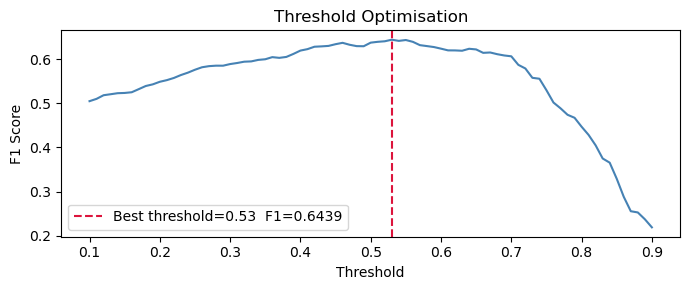

  Optimal threshold: 0.53  |  F1: 0.6439

  Final Classification Report (threshold=0.53):
              precision    recall  f1-score   support

    No Churn       0.91      0.77      0.83      1035
       Churn       0.55      0.78      0.64       374

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409



In [45]:
rf_param_dist = {
    'n_estimators'     : [100, 200, 300, 400, 500],
    'max_depth'        : [5, 7, 10, 12, 15, None],
    'max_features'     : ['sqrt', 'log2', 0.5],
    'min_samples_leaf' : randint(1, 20),
    'min_samples_split': randint(2, 30),
    'bootstrap'        : [True, False],
}

rf_results = run_model_workflow(
    name       = 'Random Forest',
    model      = RandomForestClassifier(class_weight='balanced',
                                        random_state=RANDOM_STATE),
    param_dist = rf_param_dist,
    X_tr       = X_train,
    y_tr       = y_train,
    X_te       = X_test,
    y_te       = y_test,
)
results_list.append(rf_results)

---
## Part 3 -- Gradient Boosting Models

Gradient Boosting trains an ensemble of weak learners sequentially, each correcting
the residuals of the previous. Modern implementations (XGBoost, LightGBM, CatBoost)
add regularisation terms, making them extremely competitive on tabular data.

**Early stopping** is applied using a held-out validation set to prevent overfitting
and automatically determine the optimal number of boosting rounds.

### 3.1 XGBoost

**Advantages:** Level-wise tree growth; L1+L2 regularisation; handles sparse
data natively; GPU support; widely tested in production.

**Disadvantages:** Many hyperparameters; slower than LightGBM on large datasets;
higher memory usage.

### Hyperparameters Tuned
| Parameter | Description |
|-----------|-------------|
| `n_estimators` | Max trees (early stopping may reduce this) |
| `max_depth` | Tree depth |
| `learning_rate` | Step size shrinkage |
| `subsample` | Row subsampling ratio |
| `colsample_bytree` | Column subsampling per tree |
| `reg_alpha / reg_lambda` | L1 / L2 regularisation |

  XGBoost
  [1/4] Training baseline ...
  Baseline ROC-AUC: 0.8203  F1: 0.5846
  [2/4] Hyper-parameter tuning ...
  RandomizedSearchCV best roc_auc: 0.8499
  Best params: {'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 1, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
  [3/4] Evaluating on test set ...
  Tuned  ROC-AUC: 0.8476  F1: 0.6292


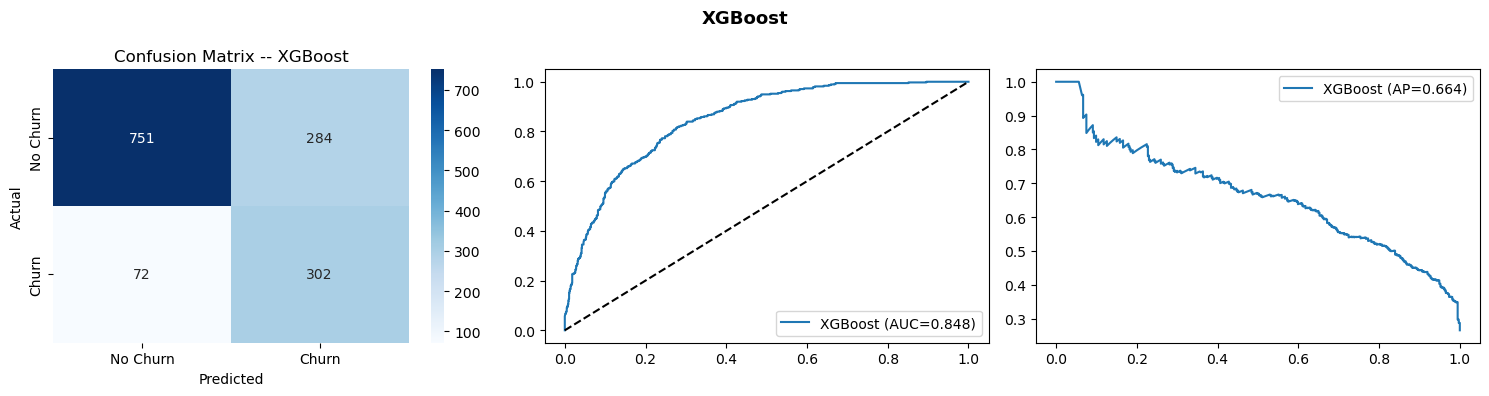

  [4/4] Threshold optimisation ...


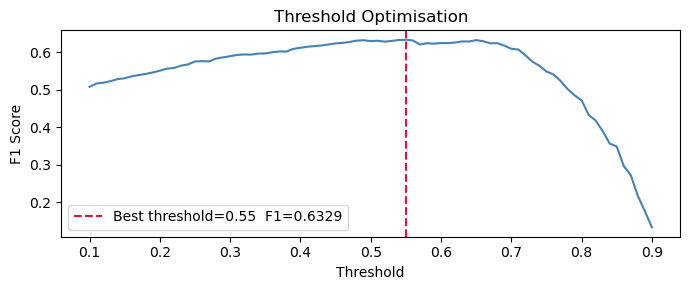

  Optimal threshold: 0.55  |  F1: 0.6329

  Final Classification Report (threshold=0.55):
              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.83      1035
       Churn       0.54      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



In [46]:
# Class imbalance weight for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_param_dist = {
    'n_estimators'     : [200, 300, 400, 500],
    'max_depth'        : [3, 4, 5, 6, 7],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha'        : [0, 0.01, 0.1, 0.5, 1],
    'reg_lambda'       : [1, 1.5, 2, 3, 5],
    'min_child_weight' : [1, 3, 5, 7],
}

xgb_results = run_model_workflow(
    name       = 'XGBoost',
    model      = XGBClassifier(
                     scale_pos_weight=scale_pos_weight,
                     eval_metric='logloss',
                     random_state=RANDOM_STATE,
                     verbosity=0,
                 ),
    param_dist = xgb_param_dist,
    X_tr       = X_train,
    y_tr       = y_train,
    X_te       = X_test,
    y_te       = y_test,
)
results_list.append(xgb_results)

### 3.2 LightGBM

**Advantages:** Leaf-wise tree growth is more efficient than level-wise; histogram-
based binning drastically speeds up training; excellent on large datasets.

**Disadvantages:** Can overfit on small datasets if `num_leaves` is large;
leaf-wise growth may be less stable than level-wise.

  LightGBM
  [1/4] Training baseline ...
  Baseline ROC-AUC: 0.8347  F1: 0.6275
  [2/4] Hyper-parameter tuning ...
  RandomizedSearchCV best roc_auc: 0.8476
  Best params: {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0, 'num_leaves': 50, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
  [3/4] Evaluating on test set ...
  Tuned  ROC-AUC: 0.8448  F1: 0.6359


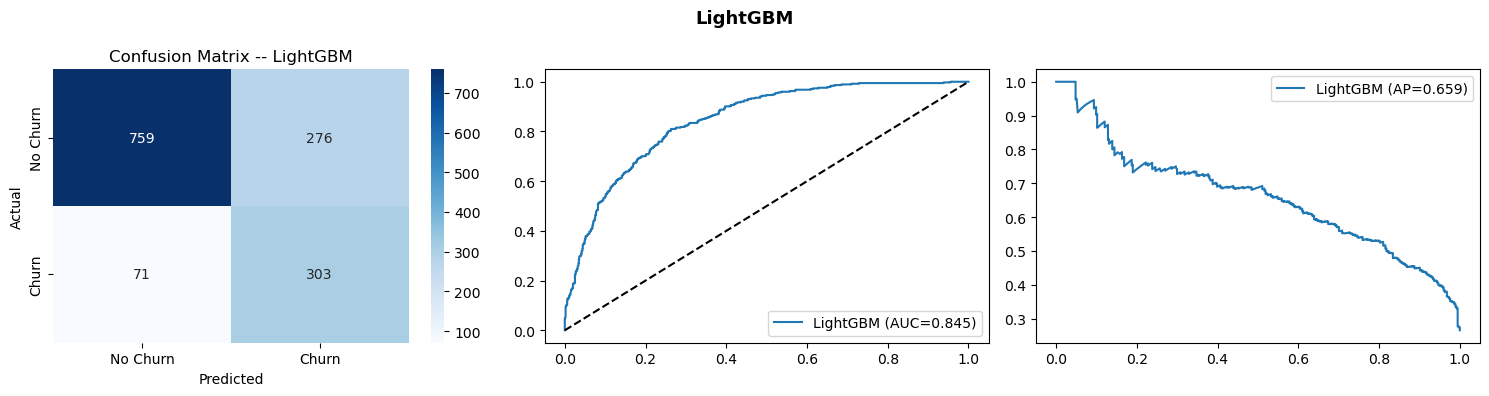

  [4/4] Threshold optimisation ...


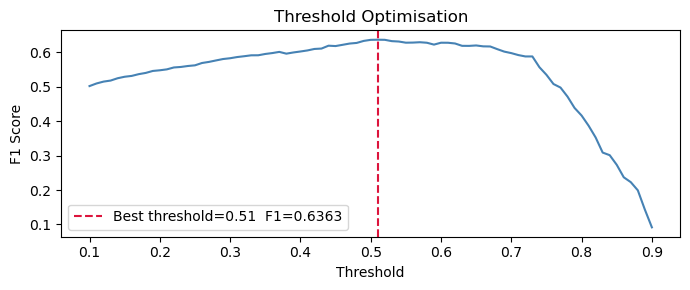

  Optimal threshold: 0.51  |  F1: 0.6363

  Final Classification Report (threshold=0.51):
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.82      1035
       Churn       0.53      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



In [47]:
lgbm_param_dist = {
    'n_estimators'  : [200, 300, 400, 500],
    'num_leaves'    : [20, 31, 50, 70, 100],
    'max_depth'     : [-1, 5, 7, 10],
    'learning_rate' : [0.01, 0.05, 0.1, 0.15],
    'subsample'     : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'reg_alpha'     : [0, 0.01, 0.1, 0.5],
    'reg_lambda'    : [0, 0.01, 0.1, 1],
    'min_child_samples': [10, 20, 30, 50],
}

lgbm_results = run_model_workflow(
    name       = 'LightGBM',
    model      = LGBMClassifier(
                     class_weight='balanced',
                     random_state=RANDOM_STATE,
                     verbose=-1,
                 ),
    param_dist = lgbm_param_dist,
    X_tr       = X_train,
    y_tr       = y_train,
    X_te       = X_test,
    y_te       = y_test,
)
results_list.append(lgbm_results)

### 3.3 CatBoost

**Advantages:** Native handling of categorical features; symmetric trees reduce
overfitting; excellent performance with default parameters; built-in early stopping.

**Disadvantages:** Slower training than LightGBM; larger model footprint; verbose
output by default (suppressed with `verbose=0`).

  CatBoost
  [1/4] Training baseline ...
  Baseline ROC-AUC: 0.8411  F1: 0.6272
  [2/4] Hyper-parameter tuning ...
  RandomizedSearchCV best roc_auc: 0.8500
  Best params: {'learning_rate': 0.01, 'l2_leaf_reg': 1, 'iterations': 500, 'depth': 4, 'border_count': 128, 'bagging_temperature': 0}
  [3/4] Evaluating on test set ...
  Tuned  ROC-AUC: 0.8484  F1: 0.6281


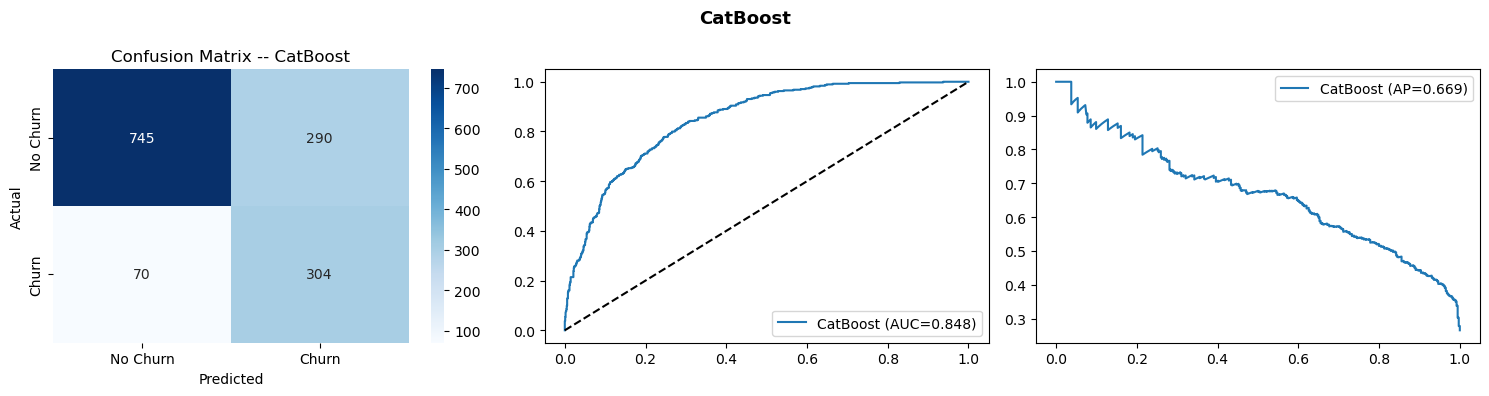

  [4/4] Threshold optimisation ...


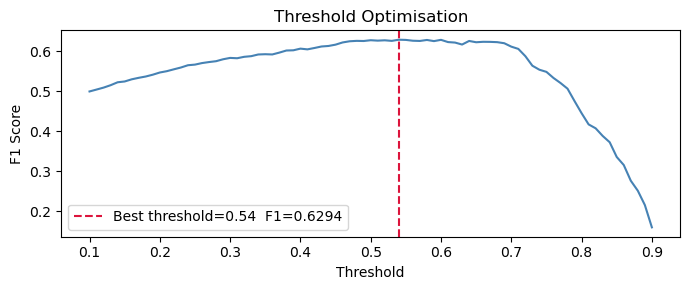

  Optimal threshold: 0.54  |  F1: 0.6294

  Final Classification Report (threshold=0.54):
              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.82      1035
       Churn       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



In [48]:
cb_param_dist = {
    'iterations'   : [200, 300, 400, 500],
    'depth'        : [4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'l2_leaf_reg'  : [1, 3, 5, 7, 10],
    'border_count' : [32, 64, 128],
    'bagging_temperature': [0, 0.5, 1.0],
}

cb_results = run_model_workflow(
    name       = 'CatBoost',
    model      = CatBoostClassifier(
                     auto_class_weights='Balanced',
                     random_state=RANDOM_STATE,
                     verbose=0,
                 ),
    param_dist = cb_param_dist,
    X_tr       = X_train,
    y_tr       = y_train,
    X_te       = X_test,
    y_te       = y_test,
)
results_list.append(cb_results)

---
## Part 4 -- Model Comparison & Selection

We aggregate every model's test-set metrics into a single leaderboard, then
visualise curves and feature importance to select the production candidate.

### Selection Criteria
- **Primary:** ROC-AUC -- measures ranking ability across all thresholds; robust to
  class imbalance.
- **Secondary:** F1-score at the optimised threshold -- balances precision and recall
  for the business decision (missed churners vs. wasted retention spend).
- **Tie-breaker:** PR-AUC -- especially important under class imbalance, where
  ROC-AUC can be overly optimistic.

In [49]:
# -"-" Leaderboard -"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"
leaderboard_cols = [
    'Model','Accuracy','Precision','Recall','F1',
    'ROC-AUC','PR-AUC','Best Threshold','Train Time (s)','Inf Time (s)'
]
leaderboard = (
    pd.DataFrame(results_list)[leaderboard_cols]    
    .sort_values(by=["Recall", "F1", "ROC-AUC"],ascending=[False, False, False])
    .reset_index(drop=True)
)
leaderboard.index += 1  # rank starts at 1
display(leaderboard.style
        .background_gradient(subset=['ROC-AUC','F1','PR-AUC'], cmap='Greens')
        .format(precision=4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Best Threshold,Train Time (s),Inf Time (s)
1,LightGBM,0.7566,0.5272,0.8021,0.6363,0.8448,0.6595,0.5100,0.1969,0.0129
2,Random Forest,0.7708,0.5478,0.7807,0.6439,0.8460,0.6570,0.5300,3.4709,0.0571
3,XGBoost,0.7637,0.5385,0.7674,0.6329,0.8476,0.6640,0.5500,0.3319,0.0066
4,CatBoost,0.7601,0.5335,0.7674,0.6294,0.8484,0.6690,0.5400,1.2525,0.0034
5,Decision Tree,0.7615,0.5363,0.7513,0.6258,0.8327,0.6194,0.6000,0.0309,0.0019
6,Lasso LR (L1),0.7608,0.5361,0.7353,0.6201,0.8407,0.6271,0.5700,0.6493,0.0005
7,Ridge LR (L2),0.7608,0.5361,0.7353,0.6201,0.8406,0.6269,0.5700,0.0156,0.0006
8,Elastic Net LR,0.7608,0.5361,0.7353,0.6201,0.8406,0.6269,0.5700,0.4521,0.0005


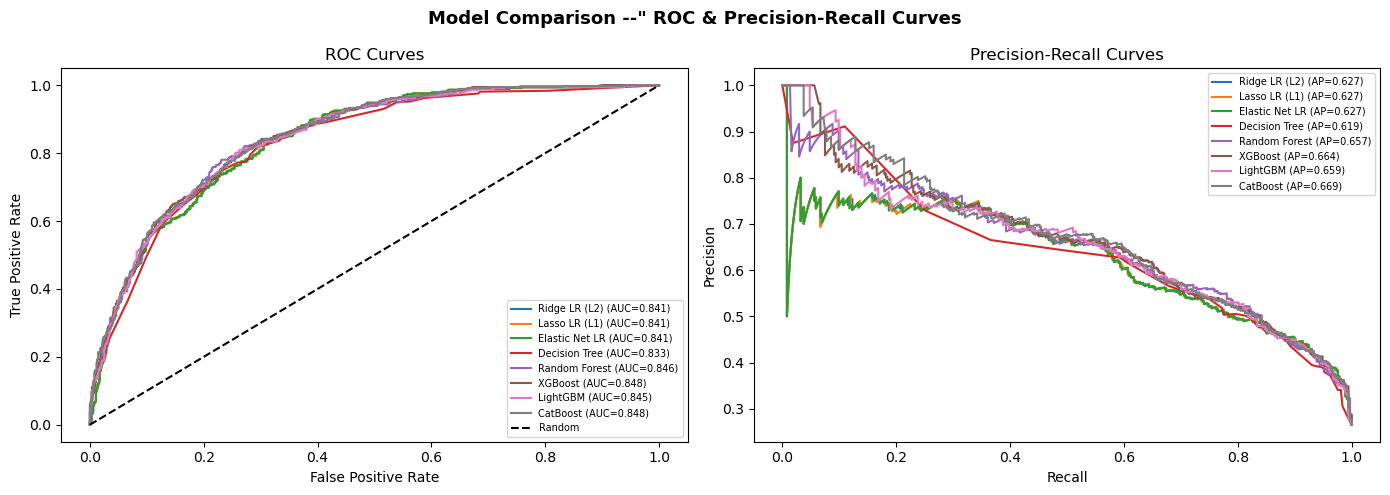

In [50]:
# -"-" ROC Comparison -"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"
COLORS = plt.cm.tab10.colors

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison --" ROC & Precision-Recall Curves', fontsize=13,
             fontweight='bold')

for i, r in enumerate(results_list):
    c = COLORS[i % len(COLORS)]
    plot_roc_curve(y_test, r['_y_proba'], r['Model'], ax=ax_roc, color=c)
    plot_pr_curve (y_test, r['_y_proba'], r['Model'], ax=ax_pr,  color=c)

ax_roc.plot([0,1],[0,1],'k--', label='Random')
ax_roc.set_xlabel('False Positive Rate'); ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curves'); ax_roc.legend(fontsize=7)

ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curves'); ax_pr.legend(fontsize=7)

plt.tight_layout(); plt.show()

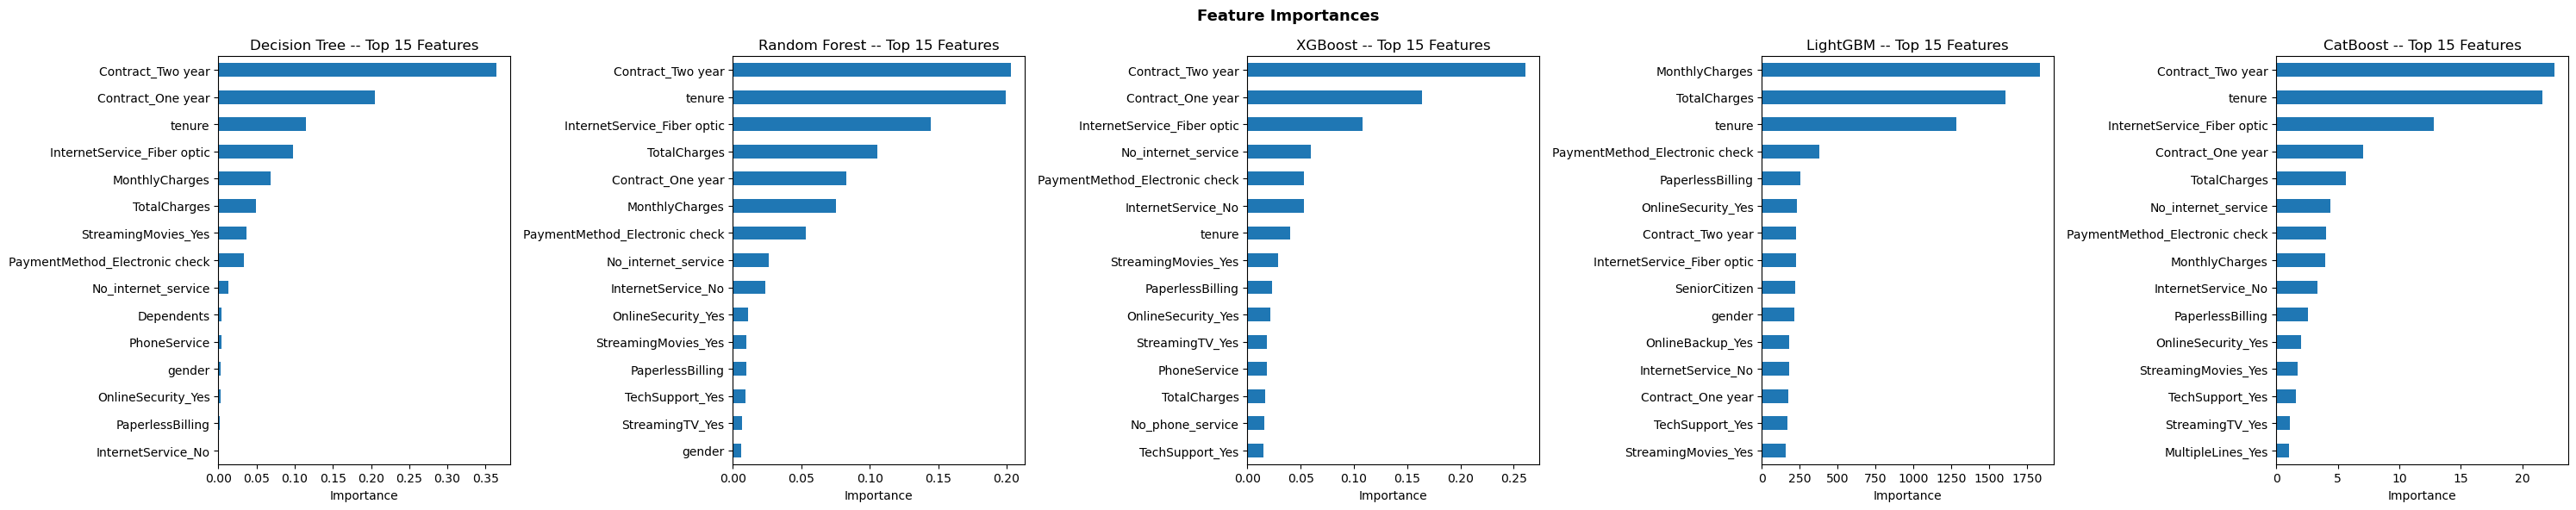

In [51]:
# -- Feature Importance (tree / boosting models) -------------------------
feature_names = X_train.columns.tolist()

tree_results = [r for r in results_list
                if hasattr(r['_model'], 'feature_importances_')]

n_models = len(tree_results)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 6))
if n_models == 1: axes = [axes]

for ax, r in zip(axes, tree_results):
    fi = pd.Series(r['_model'].feature_importances_, index=feature_names)
    fi.sort_values(ascending=True).tail(15).plot(kind='barh', ax=ax)
    ax.set_title(r['Model'] + ' -- Top 15 Features')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importances', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [52]:
# -"-" Select Best Model -"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"
best_row   = leaderboard.iloc[0]   # sorted by ROC-AUC
best_name  = best_row['Model']
best_result = next(r for r in results_list if r['Model'] == best_name)
best_model = best_result['_model']

print(f'Selected model: {best_name}')
print(f'  ROC-AUC : {best_row["ROC-AUC"]}')
print(f'  F1      : {best_row["F1"]}')
print(f'  PR-AUC  : {best_row["PR-AUC"]}')

# Brief explanation
print(f"""
Selection Rationale
-------------------
{best_name} was selected as the production model because it achieved the
highest ROC-AUC ({best_row['ROC-AUC']:.4f}) and a strong F1-score ({best_row['F1']:.4f})
at its optimised threshold ({best_row['Best Threshold']}).  ROC-AUC is the primary
criterion because it evaluates ranking across all possible thresholds, which is
appropriate when the decision threshold may be adjusted based on campaign economics.
""")

Selected model: LightGBM
  ROC-AUC : 0.8448
  F1      : 0.6363
  PR-AUC  : 0.6595

Selection Rationale
-------------------
LightGBM was selected as the production model because it achieved the
highest ROC-AUC (0.8448) and a strong F1-score (0.6363)
at its optimised threshold (0.51).  ROC-AUC is the primary
criterion because it evaluates ranking across all possible thresholds, which is
appropriate when the decision threshold may be adjusted based on campaign economics.



### SHAP Analysis

SHAP (SHapley Additive exPlanations) provides a unified, game-theoretically
grounded measure of each feature's contribution to every individual prediction.
Unlike model-native importances (gain, impurity), SHAP values are consistent and
locally faithful, making them the recommended approach for model explainability.

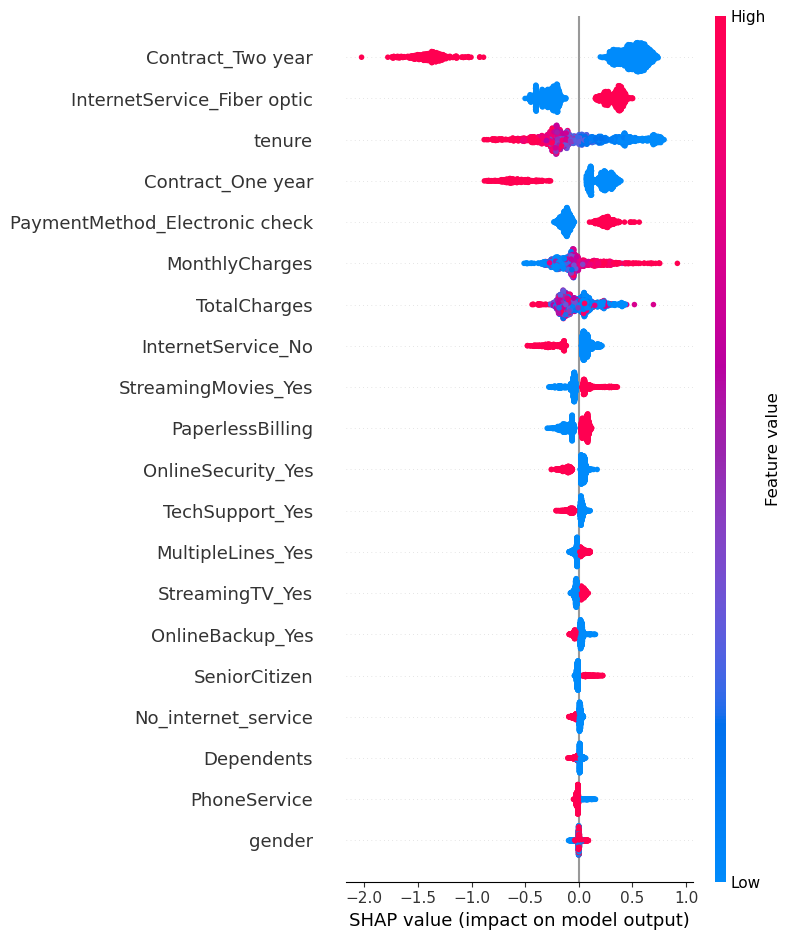

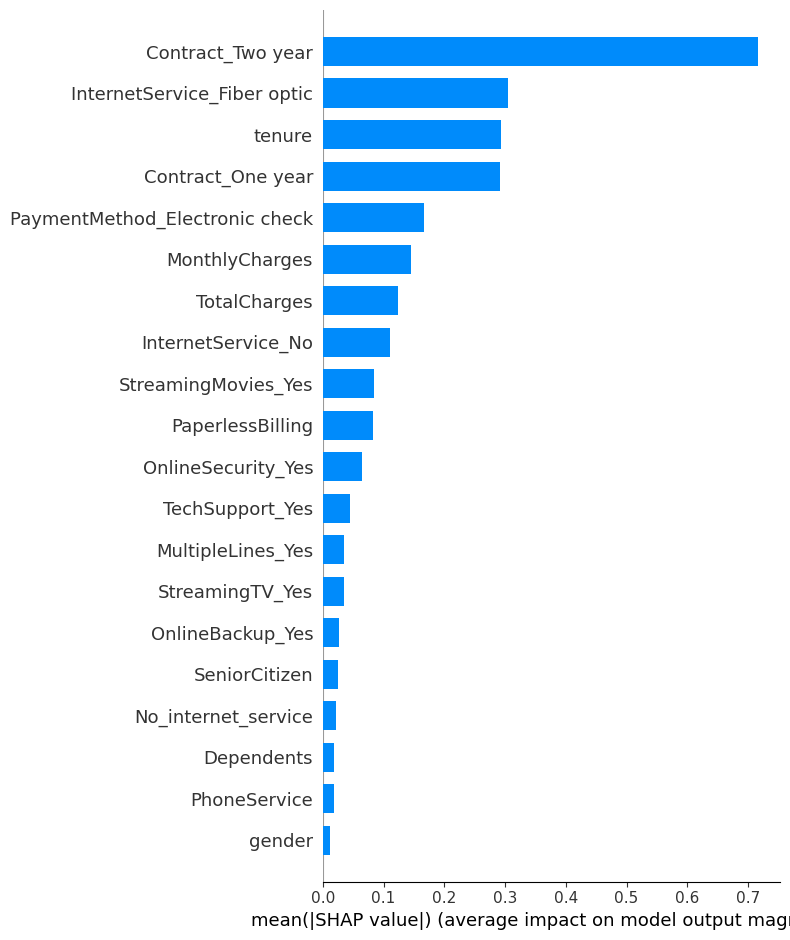

In [53]:
# -"-" SHAP Explainability for Best Model -"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"
# Use TreeExplainer for tree/boosting models, KernelExplainer otherwise
if hasattr(best_model, 'feature_importances_'):
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    # For binary classifiers, shap_values may be a list; take class-1 values
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values
else:
    # Logistic regression --" use LinearExplainer
    explainer = shap.LinearExplainer(best_model, X_test_scaled,
                                     feature_perturbation='interventional')
    sv = explainer.shap_values(X_test_scaled)
    X_test_for_shap = X_test_scaled

X_test_for_shap = X_test if hasattr(best_model, 'feature_importances_') else X_test_scaled

# Beeswarm (summary) plot
plt.figure()
shap.summary_plot(sv, X_test_for_shap, feature_names=feature_names,
                  max_display=20, show=True)

# Bar plot --" mean |SHAP|
plt.figure()
shap.summary_plot(sv, X_test_for_shap, feature_names=feature_names,
                  plot_type='bar', max_display=20, show=True)

---
## Part 5 -- MLflow Experiment Tracking & Model Registry

MLflow provides experiment tracking, reproducibility, and model lifecycle management.
Every model run is logged with:

| Artifact | Description |
|----------|-------------|
| **Parameters** | Full hyper-parameter set from `get_params()` + best threshold |
| **Metrics** | Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, train/inf time |
| **Confusion Matrix** | PNG saved as artifact |
| **ROC Curve** | PNG saved as artifact |
| **PR Curve** | PNG saved as artifact |
| **Feature Importance** | PNG saved for tree/boosting models |
| **Model** | Serialised model registered in the Model Registry |

Run `mlflow ui` in the project directory to launch the tracking dashboard.

In [54]:
# Configure MLflow tracking
mlflow.set_tracking_uri(MLFLOW_URI)
print(f'MLflow tracking URI: {mlflow.get_tracking_uri()}')
print('Logging all models to MLflow ...')

run_ids = {}
for r in results_list:
    print(f'\nLogging: {r["Model"]}')
    rid = log_mlflow_run(
        result          = r,
        X_te            = X_test,
        y_te            = y_test,
        experiment_name = 'customer_churn',
        feature_names   = feature_names,
    )
    run_ids[r['Model']] = rid

print('\nAll runs logged successfully.')

MLflow tracking URI: sqlite:///mlflow.db
Logging all models to MLflow ...

Logging: Ridge LR (L2)
  MLflow run logged: 897c0b4ac89b47e7bed16d3dcc8ae0e1

Logging: Lasso LR (L1)
  MLflow run logged: 9966fd53398546d7bebf8327ea0d30e8

Logging: Elastic Net LR
  MLflow run logged: 432aa107f26f4b35b023118afd3b4aaa

Logging: Decision Tree
  MLflow run logged: 198153bc464947b6af998d704fae2298

Logging: Random Forest
  MLflow run logged: 93d32fdbe10f4a89954b148dc245befb

Logging: XGBoost
  MLflow run logged: fbd45d2843c54e5a85eb417e10c20121

Logging: LightGBM
  MLflow run logged: d4974fa924fd47e69d1558c48e23dac0

Logging: CatBoost
  MLflow run logged: b4a55e591b5c4247b6b42112e6a81174

All runs logged successfully.


In [55]:
# -"-" Register Best Model in MLflow Model Registry -"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"-"
best_run_id   = run_ids[best_name]
model_uri     = f'runs:/{best_run_id}/model'
registry_name = 'CustomerChurnBestModel'

mv = mlflow.register_model(model_uri=model_uri, name=registry_name)

print(f'Registered model : {registry_name}')
print(f'Model version    : {mv.version}')
print(f'Run ID           : {best_run_id}')
print(f'Source model     : {best_name}')

Registered model 'CustomerChurnBestModel' already exists. Creating a new version of this model...
2026/07/04 21:53:20 WARNING mlflow.tracking._model_registry.fluent: Run with id d4974fa924fd47e69d1558c48e23dac0 has no artifacts at artifact path 'model', registering model based on models:/m-5e14ce731d1e47aca22f401d0de5a975 instead


Registered model : CustomerChurnBestModel
Model version    : 2
Run ID           : d4974fa924fd47e69d1558c48e23dac0
Source model     : LightGBM


Created version '2' of model 'CustomerChurnBestModel'.


In [56]:
# Transition the newly registered version to Staging
from mlflow.tracking import MlflowClient

client = MlflowClient()
try:
    client.transition_model_version_stage(
        name    = registry_name,
        version = mv.version,
        stage   = 'Staging',
    )
    print(f'{registry_name} v{mv.version} transitioned to Staging.')
except Exception as e:
    # MLflow 3.x deprecated stage transitions; use tags instead
    client.set_model_version_tag(registry_name, mv.version, 'stage', 'Staging')
    print(f'{registry_name} v{mv.version} tagged as Staging (MLflow 3.x).')
print('Run  `mlflow ui`  in the terminal to inspect all runs and the registry.')

CustomerChurnBestModel v2 transitioned to Staging.
Run  `mlflow ui`  in the terminal to inspect all runs and the registry.


---
## Final Model Leaderboard

All models ranked by ROC-AUC (descending). The selected production model is
highlighted by rank 1.

In [58]:
print('\n' + '='*70)
print('CUSTOMER CHURN MODEL LEADERBOARD  (sorted by Recall desc)')
print('='*70)
display(leaderboard.style
        .background_gradient(subset=['ROC-AUC','F1','PR-AUC'], cmap='RdYlGn')
        .highlight_max(subset=['ROC-AUC','F1','PR-AUC'], color='lightgreen')
        .format(precision=4)
        .set_caption(f'Production model: {best_name}'))


CUSTOMER CHURN MODEL LEADERBOARD  (sorted by Recall desc)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Best Threshold,Train Time (s),Inf Time (s)
1,LightGBM,0.7566,0.5272,0.8021,0.6363,0.8448,0.6595,0.5100,0.1969,0.0129
2,Random Forest,0.7708,0.5478,0.7807,0.6439,0.8460,0.6570,0.5300,3.4709,0.0571
3,XGBoost,0.7637,0.5385,0.7674,0.6329,0.8476,0.6640,0.5500,0.3319,0.0066
4,CatBoost,0.7601,0.5335,0.7674,0.6294,0.8484,0.6690,0.5400,1.2525,0.0034
5,Decision Tree,0.7615,0.5363,0.7513,0.6258,0.8327,0.6194,0.6000,0.0309,0.0019
6,Lasso LR (L1),0.7608,0.5361,0.7353,0.6201,0.8407,0.6271,0.5700,0.6493,0.0005
7,Ridge LR (L2),0.7608,0.5361,0.7353,0.6201,0.8406,0.6269,0.5700,0.0156,0.0006
8,Elastic Net LR,0.7608,0.5361,0.7353,0.6201,0.8406,0.6269,0.5700,0.4521,0.0005
